In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
vocab_size = 27
n_embd = 10
block_size = 3

In [4]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

In [17]:
class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True # many different modules have different behaviors in train & test. in train we use the mean & variance of the current batch, but if we test we use the running mean & the running std.

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):

        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar  = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta # torch modules don't have these by default, we're implementing this here for easier debugging.

        if self.training:
            with torch.no_grad(): # turn off grad so torch doesn't start building a computational graph for these ops
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
            return self.out

    def parameters(self):
        return [self.gamma, self.beta]

In [18]:
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
        
    def parameters(self):
        return []

In [19]:
n_embd = 10 # dimensionality
n_hidden = 100 # number of neurons in the hidden layer
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd*block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(        n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(        n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(        n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(        n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(        n_hidden, vocab_size), 
]

In [41]:
# apply Kaiming init to every layer except the last.
with torch.no_grad(): 
    layers[-1].weight *= 0.1 # why???
    for layer in layers[:-1]: 
        if isinstance(layer, Linear):
            layer.weight *= 1

parameters = [C] + [p for layer in layers for p in layer.parameters()]

In [42]:
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

47497


In [43]:
words = open('names.txt', 'r').read().splitlines() #load our dataset
stoi = {s: i+1 for i, s in enumerate(sorted(list(set(''.join(words)))))}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()} #create our dictionary

In [44]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)

            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape) # should be (vocab_size, block_size) and (vocab_size)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [45]:
max_steps = 200000
batch_size = 32
lossi= []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1) 
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters: 
        p.data += -lr * p.grad

    # track stats
    if i % 1000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    #break

      0/ 200000: 2.9030
   1000/ 200000: 2.1365
   2000/ 200000: 2.6291
   3000/ 200000: 2.2558
   4000/ 200000: 1.7449
   5000/ 200000: 2.5263
   6000/ 200000: 2.2465
   7000/ 200000: 2.0713
   8000/ 200000: 1.9520
   9000/ 200000: 1.9256
  10000/ 200000: 2.0825
  11000/ 200000: 1.8970
  12000/ 200000: 2.1928
  13000/ 200000: 2.0992
  14000/ 200000: 2.2493
  15000/ 200000: 2.2907
  16000/ 200000: 1.9868
  17000/ 200000: 1.7238
  18000/ 200000: 2.0134
  19000/ 200000: 2.1302
  20000/ 200000: 1.9412
  21000/ 200000: 2.1099
  22000/ 200000: 2.4439
  23000/ 200000: 2.4996
  24000/ 200000: 2.0244
  25000/ 200000: 2.0833
  26000/ 200000: 2.1695
  27000/ 200000: 2.0213
  28000/ 200000: 2.0846
  29000/ 200000: 2.3332
  30000/ 200000: 2.1334
  31000/ 200000: 2.2598
  32000/ 200000: 2.1277
  33000/ 200000: 2.1022
  34000/ 200000: 2.1564
  35000/ 200000: 1.9699
  36000/ 200000: 2.4062
  37000/ 200000: 2.7266
  38000/ 200000: 2.4806
  39000/ 200000: 2.2741
  40000/ 200000: 2.1760
  41000/ 200000:

layer 2 (      Tanh): mean -0.00, std 0.71, saturated: 19.09%
layer 5 (      Tanh): mean +0.00, std 0.76, saturated: 22.78%
layer 8 (      Tanh): mean -0.03, std 0.78, saturated: 22.62%
layer 11 (      Tanh): mean -0.01, std 0.80, saturated: 24.41%
layer 14 (      Tanh): mean +0.01, std 0.57, saturated: 7.19%


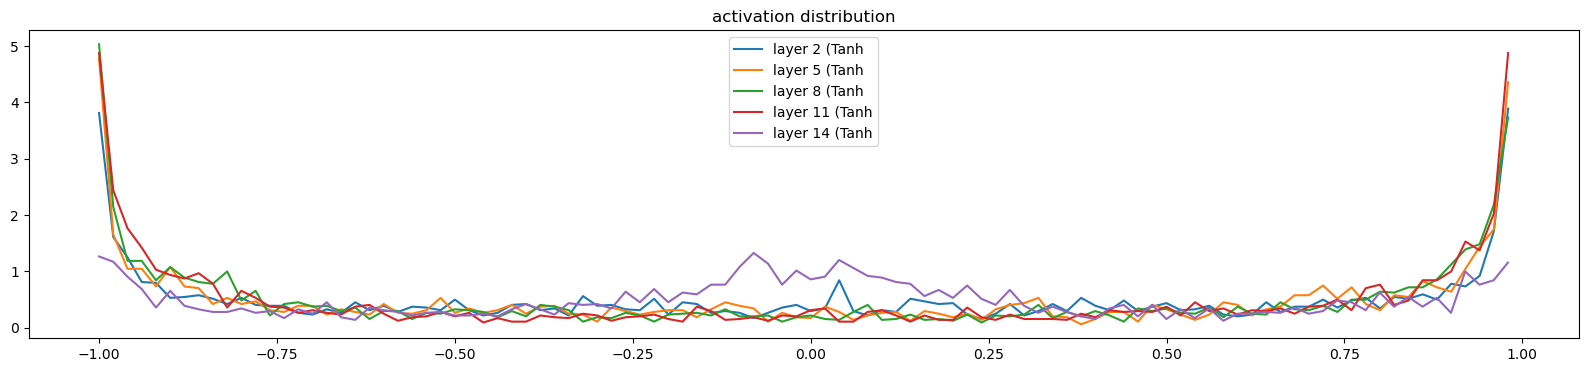

In [46]:
# visualize the histogram

plt.figure(figsize = (20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
    plt.legend(legends);
    plt.title('activation distribution'''')

layer 2 (      Tanh): mean -0.000000, std 3.936814e-03
layer 5 (      Tanh): mean -0.000000, std 3.774506e-03
layer 8 (      Tanh): mean -0.000000, std 3.556396e-03
layer 11 (      Tanh): mean +0.000000, std 3.371233e-03
layer 14 (      Tanh): mean +0.000027, std 5.604881e-03


Text(0.5, 1.0, 'activation distribution')

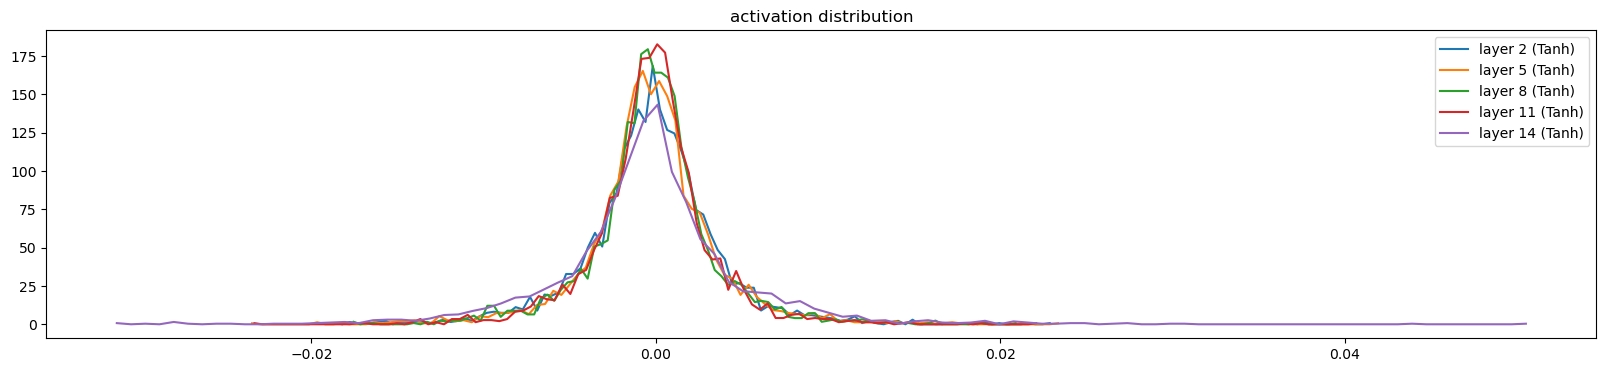

In [47]:
# visualize histograms

plt.figure(figsize = (20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')

In [49]:
# Issue was my not calling BatchNorm1d despite creating the class
# It used to be much harder before BatchNorm1d since we had to balance the initializations much more carefully than we need know.